# E-Commerce Sales Analysis: EDA

## Step 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 2:Dataset download and initial review

In [3]:
df = pd.read_csv('H:/projects/kaggle/ecommerce_sales_analytics_5000.csv')
df.sample(10)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
692,10693,11/24/2023,1159,Clothing,West,7,262.46,0.19,Card,10,3.8,1488.15
2885,12886,11/25/2029,1821,Home,North,1,347.71,0.00,COD,1,2.4,347.71
2547,12548,12/22/2028,1317,Clothing,North,7,499.45,0.34,COD,9,1.1,2307.46
1896,11897,3/12/2027,1288,Clothing,South,2,154.92,0.10,Card,8,4.6,278.86
4096,14097,3/20/2033,1467,Home,South,3,82.77,0.01,COD,9,4.0,245.83
4599,14600,8/5/2034,1234,Electronics,North,1,447.51,0.12,Card,8,4.8,393.81
4287,14288,9/27/2033,1595,Clothing,West,3,72.45,0.23,Card,11,2.2,167.36
865,10866,5/15/2024,1216,Home,East,2,222.75,0.03,Wallet,5,3.3,432.14
2830,12831,10/1/2029,1743,Beauty,West,3,50.46,0.07,COD,1,3.9,140.78
1217,11218,5/2/2025,1473,Clothing,East,2,427.32,0.11,Card,1,1.5,760.63


### Information about dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum().to_frame(name='Null Count')

,Null Count
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


The dataset is clean: there are no gaps or duplicates.

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce') #Set order_date from str to datetime

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,5000.0,12500.5,10001.0,11250.75,12500.5,13750.25,15000.0,1443.520003
order_date,5000,2028-11-04 12:00:00,2022-01-01 00:00:00,2025-06-03 18:00:00,2028-11-04 12:00:00,2032-04-07 06:00:00,2035-09-09 00:00:00,NaN
customer_id,5000.0,1505.7012,1000.0,1253.0,1510.0,1761.0,1999.0,290.836902
quantity,5000.0,4.0448,1.0,2.0,4.0,6.0,7.0,2.020398
unit_price,5000.0,308.418774,15.15,161.895,309.89,455.5575,599.96,169.259369
discount,5000.0,0.179984,0.0,0.09,0.18,0.27,0.35,0.101404
delivery_days,5000.0,6.1188,1.0,3.0,6.0,9.0,11.0,3.153264
customer_rating,5000.0,2.97398,1.0,2.0,3.0,4.0,5.0,1.157722
revenue,5000.0,1021.955148,11.21,354.5275,796.65,1515.69,4119.33,825.584219


In [13]:
df.describe(include=['object'])

,product_category,region,payment_method
count,5000,5000,5000
unique,4,4,3
top,Electronics,West,Card
freq,1777,1289,2270


In [15]:
df['product_category'].value_counts()

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64

In [16]:
df['region'].value_counts()

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64

In [17]:
df['payment_method'].value_counts()

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

**Product categories:**
The dataset contains 4 product categories.
The category with the most orders is "Electronics" (1777 orders, ~35.5% of all orders), followed by "Clothing" (1531, ~30.6%). The least popular category is "Beauty" (only 723 orders, ~14.5%).

**Regions:**
There are 4 regions with a fairly even distribution of orders (from 1208 to 1289). The "West" region has a slight advantage (1289), while the "South" region has minimal activity (1208). This indicates a balanced geographical coverage.

**Payment methods:**
There are 3 payment options. The "Card" option is the absolute leader (2270 orders, 45.4%), indicating a preference for cashless payments.
The "COD" (Cash on Delivery) option is in second place with 1774 orders (35.5%). The least popular is "Wallet" (956, 19.1%).

Check the emissions

In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = df[num_cols] < (Q1 - 1.5*IQR)
upper_bound = df[num_cols] > (Q3 + 1.5*IQR)

(lower_bound | upper_bound).sum().to_frame(name='Emissions')

,Emissions
order_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
delivery_days,0
customer_rating,0
revenue,67


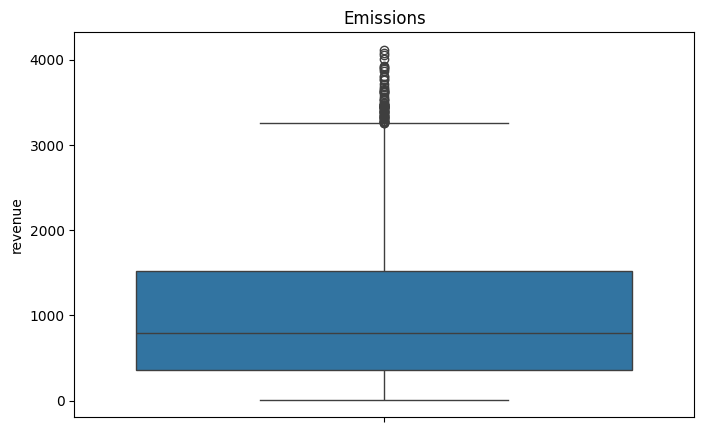

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='revenue')
plt.title('Emissions')
plt.show()

We can observe a significant number of revenue emissions.

## Step 3: EDA

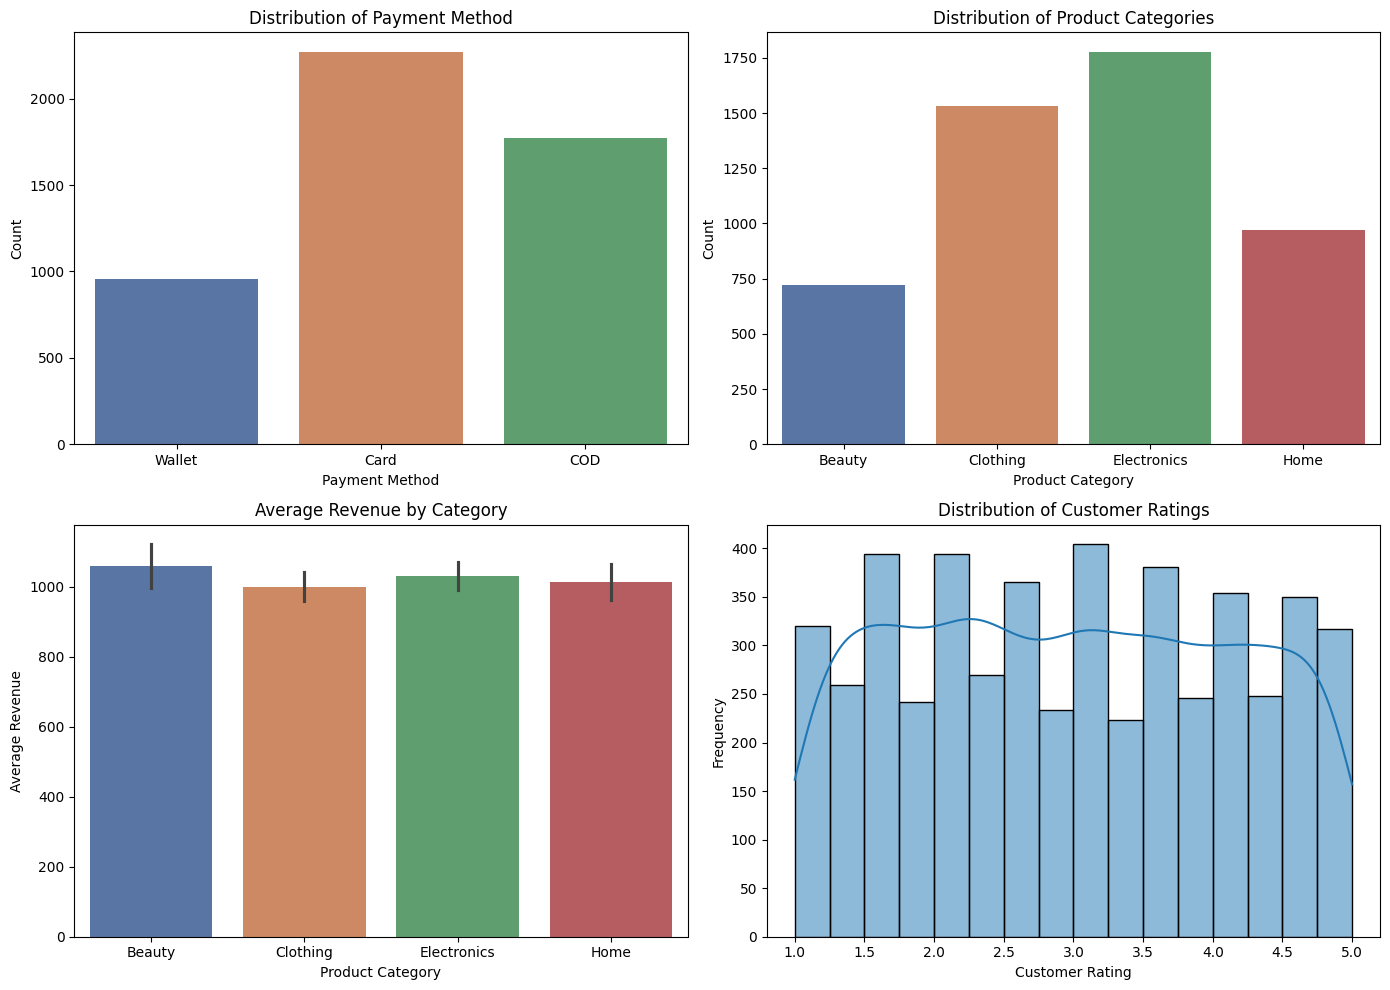

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='payment_method', palette='deep', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Payment Method', fontsize=12)
axes[0, 0].set_xlabel('Payment Method')
axes[0, 0].set_ylabel('Count')

sns.countplot(data=df, x='product_category', palette='deep', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Product Categories', fontsize=12)
axes[0, 1].set_xlabel('Product Category')
axes[0, 1].set_ylabel('Count')

sns.barplot(data=df, x='product_category', y='revenue', palette='deep', ax=axes[1, 0])
axes[1, 0].set_title('Average Revenue by Category', fontsize=12)
axes[1, 0].set_xlabel('Product Category')
axes[1, 0].set_ylabel('Average Revenue')

sns.histplot(data=df, bins=16, x='customer_rating', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Customer Ratings', fontsize=12)
axes[1, 1].set_xlabel('Customer Rating')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Visual analysis shows:**

- Payment methods: a clear dominance of cards (45%), with minimal use of wallets (19%).

- Product categories: Electronics and Clothing account for ~66% of all orders, while Beauty is the least popular.

- Revenue by category: Despite leading in terms of order count, the Electronics category is likely to generate the highest revenue (worth checking on the chart). This may indicate higher prices for products in this category.

- Customer ratings: the distribution is close to normal, with a peak at ratings of 4-5, indicating a high level of satisfaction.

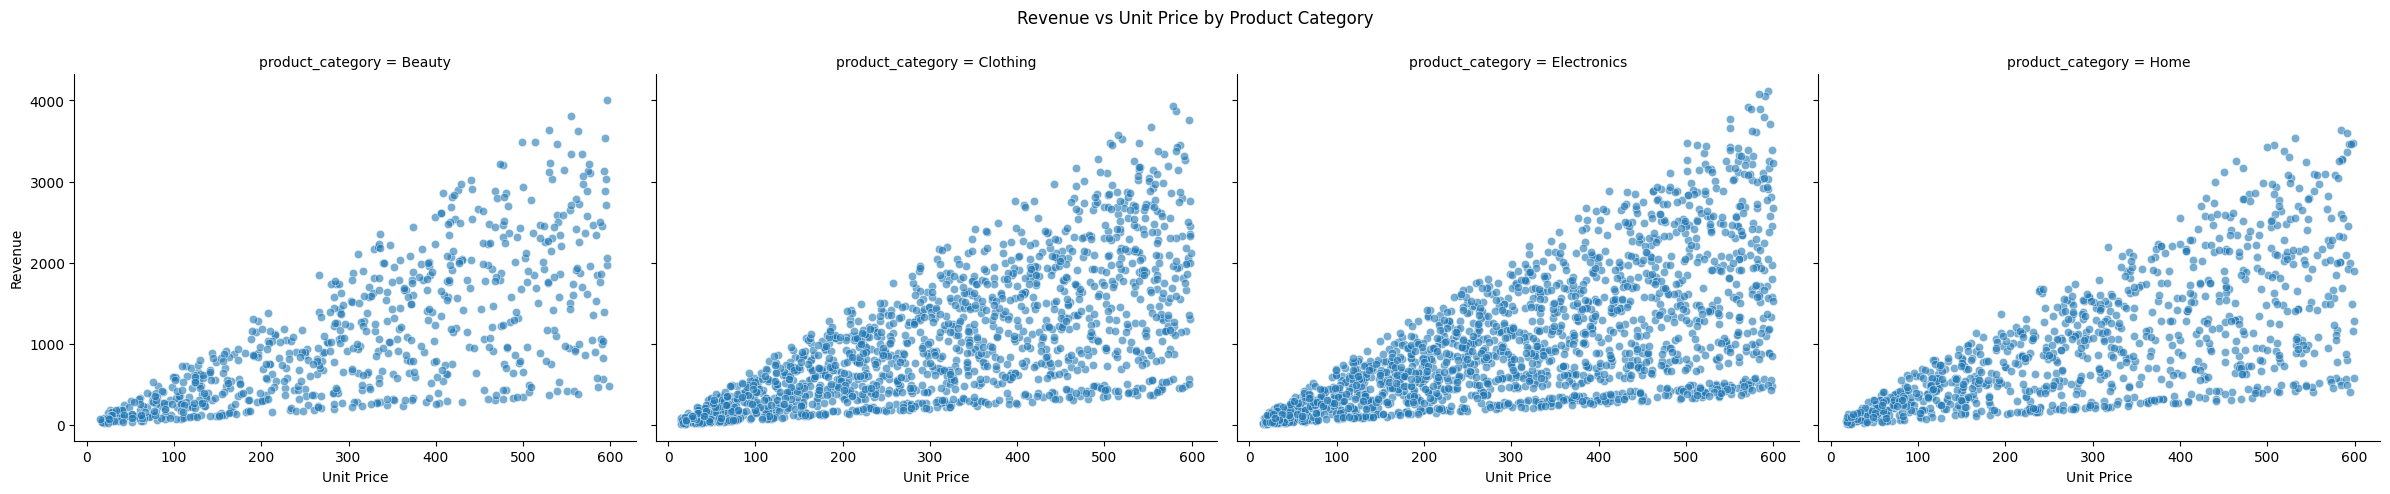

In [32]:
g = sns.FacetGrid(df, col='product_category', height=5, aspect=1.2)
g.map(sns.scatterplot, 'unit_price', 'revenue', alpha=0.6)
g.set_axis_labels('Unit Price', 'Revenue')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Revenue vs Unit Price by Product Category')
plt.show()

The analysis showed that the impact of price on revenue is highly differentiated by category. This factor is most significant in the Electronics segment, while sales volume rather than price is crucial for Beauty. These insights will enable the development of a targeted pricing and marketing strategy for each category.

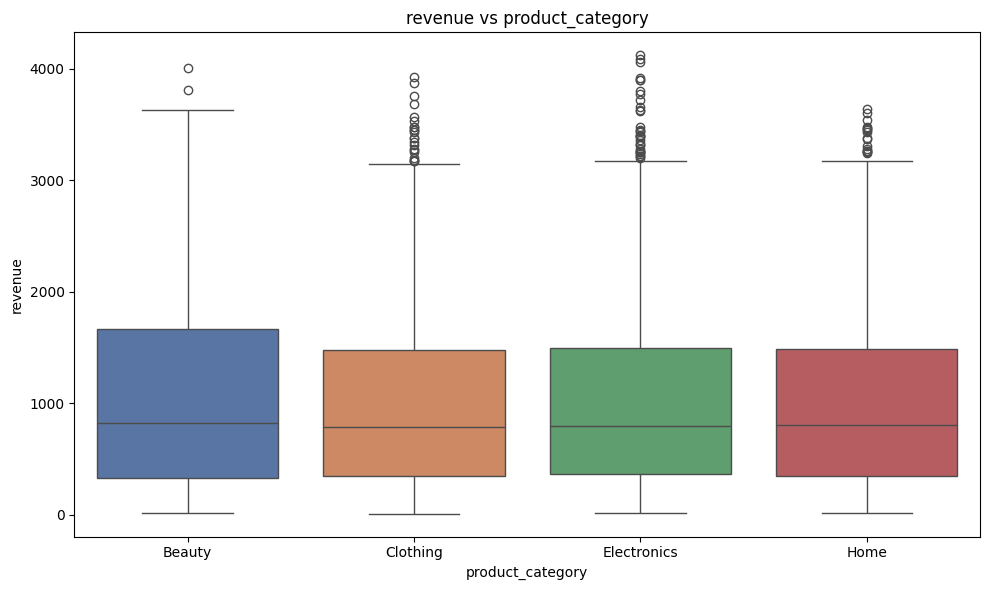

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='revenue', palette='deep')
plt.title('revenue vs product_category')
plt.tight_layout()
plt.show()

**Key findings:**
- Beauty is the most effective category in terms of stability and revenue level. It is recommended to maintain the current strategy.

- Clothing requires additional analysis to identify the reasons for high variability:
It may be worth dividing it into subcategories (men's/women's, premium/economy).
Check the impact of seasonality and discounts.

- Electronics is interesting due to the presence of large upward spikes. It is worth studying what causes them (expensive products, large wholesale orders) and scaling successful cases.

- Home is the weakest category in terms of revenue. Marketing activity is required:
Promotions and cross-sales with other categories.
Analysis of the reasons for low sales (price, assortment, demand).

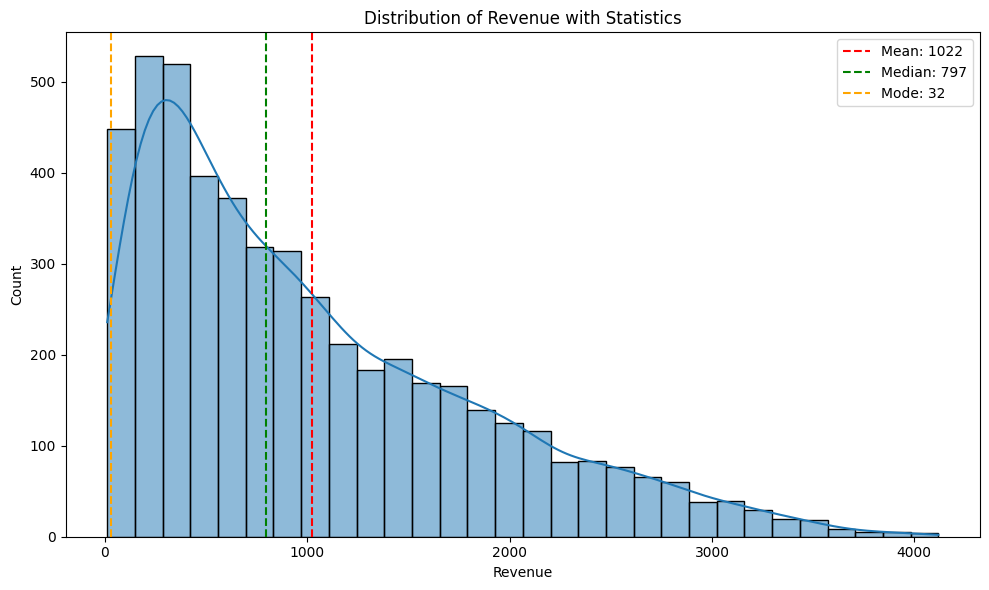

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='revenue', kde=True, bins=30)

# Добавляем вертикальные линии
mean_val = df['revenue'].mean()
median_val = df['revenue'].median()
mode_val = df['revenue'].mode()[0]

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.0f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.0f}')

plt.legend()
plt.title('Distribution of Revenue with Statistics')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Ключевые выводы по распределению выручки**
- Сильная правосторонняя асимметрия

Mean (1022) > Median (797) > Mode (32) — классический признак скошенного распределения с "длинным хвостом" вправо.

- Реальная структура продаж

Мода (32) — самый частый заказ, но с минимальной выручкой.

Медиана (797) — 50% заказов не превышают эту сумму (реальный "средний" чек).

Среднее (1022) — завышено за счёт редких крупных заказов.

- Три сегмента клиентов

Массовый: небольшие заказы (mode = 32) — основа по объёму.

Средний: до 797 — типичный чек.

Премиум: >1000–4000 — редкие, но критичные для выручки.

- Практические рекомендации

Для прогнозов использовать медиану, а не среднее.

Стимулировать массовый сегмент к повышению чека (кросс-продажи).

Выявить характеристики крупных заказов и масштабировать.

Для моделирования применить логарифмическое преобразование.